# Experiment 2 — Publication Plots (interactive)

Notebook version of `exp2_publication_plots.py`, set up for **iterating on figure style**.

**How to use:**
1. Run the setup cells (imports → paths/data → style → palette → helpers) once.
2. Edit the **Style** and **Color palette** cells, then re-run any plot cell — the new style applies immediately.
3. Each plot lives in its own cell (function definition + call). Tweak one figure without touching the others.
4. Figures render **inline**. Set `SAVE_FIGS = True` to also write PDF + PNG to `plots/notebook_plots/`.

No GPU needed — reads only the saved CSVs in `results/`.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Paths & data

Reads CSVs from the repo's `results/` folder. Toggle `SAVE_FIGS` to also export files.

In [2]:
# Resolve paths relative to this notebook (experiments/exp2_backtracking/)
BASE    = Path.cwd()
RESULTS = BASE / "results"
if not RESULTS.exists():
    # fallback if the notebook is run from the repo root
    RESULTS = BASE / "experiments" / "exp2_backtracking" / "results"
assert RESULTS.exists(), f"results dir not found at {RESULTS}"

# Output (only used when SAVE_FIGS is True)
SAVE_FIGS = False
PLOTS = BASE / "plots" / "notebook_plots"

# Input files
SIM_FILE      = RESULTS / "exp2_backtracking_text_similarity_100.csv"
HIDDEN_FILE   = RESULTS / "exp2_hidden_state_divergence_100.csv"
GRAPH_HIDDEN  = RESULTS / "exp2_graph_hidden_state_divergence_100.csv"
GRAPH_BT_FILE = RESULTS / "exp2_graph_internal_backtracking_100.csv"
SUMMARY_FILE  = RESULTS / "exp2_summary_by_question_type_100.csv"
PROBE_FILE    = RESULTS / "exp2_layer_probe_thinking_vs_answer_100.csv"
LOGIT_FILE    = RESULTS / "exp2_logit_lens_token_categories_100.csv"
QDIV_FILE     = RESULTS / "exp2_question_level_divergence_summary_100.csv"

# Load everything
sim_df       = pd.read_csv(SIM_FILE)
hidden_df    = pd.read_csv(HIDDEN_FILE)
graph_hidden = pd.read_csv(GRAPH_HIDDEN)
graph_bt_df  = pd.read_csv(GRAPH_BT_FILE)
qtype_df     = pd.read_csv(SUMMARY_FILE) if SUMMARY_FILE.exists() else pd.DataFrame()
probe_df     = pd.read_csv(PROBE_FILE)   if PROBE_FILE.exists()   else pd.DataFrame()
logit_df     = pd.read_csv(LOGIT_FILE)   if LOGIT_FILE.exists()   else pd.DataFrame()
qdiv_df      = pd.read_csv(QDIV_FILE)    if QDIV_FILE.exists()    else pd.DataFrame()

print(f"sim={len(sim_df)}  hidden={len(hidden_df)}  graph_hidden={len(graph_hidden)}  graph_bt={len(graph_bt_df)}")
print(f"qtype={len(qtype_df)}  probe={len(probe_df)}  logit={len(logit_df)}  qdiv={len(qdiv_df)}")

sim=100  hidden=3071  graph_hidden=18500  graph_bt=100
qtype=5  probe=37  logit=1260  qdiv=83


## Style — *edit here, then re-run any plot*

Global rcParams. Change fonts, spines, grid, dpi, etc. Re-running this cell updates the style used by every subsequent plot.

In [100]:
STYLE = {
    "font.size":          18,
    "axes.titlesize":     18,
    "axes.titleweight":   "bold",
    "axes.labelsize":     18,
    "axes.labelweight":   "normal",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.linewidth":     1.2,
    "axes.grid":          True,
    "grid.alpha":         0.4,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.8,
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.labelsize":    18,
    "ytick.labelsize":    18,
    "legend.fontsize":    18,
    "legend.frameon":     True,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#cccccc",
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "figure.dpi":         110,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.facecolor":  "white",
}
plt.rcParams.update(STYLE)

## Color palette — *edit here, then re-run any plot*

In [ ]:
# seaborn "deep" palette — matches Figure 1 (reasoning-trace evaluation)
C_BLUE   = "#4C72B0"   # deep blue — primary    (Graph-PRefLexOR)
C_CORAL  = "#DD8452"   # deep orange — secondary (Qwen)
C_GREEN  = "#55A868"   # deep green — tertiary   (Qwen no-thinking)
C_PURPLE = "#8172B3"   # purple
C_AMBER  = "#CCB974"   # amber/yellow
C_TEAL   = "#64B5CD"   # cyan/teal
C_BROWN  = "#937860"   # brown
C_GRAY   = "#8C8C8C"   # neutral gray

SOURCE_COLORS = {
    "qwen_thinking":    C_CORAL,
    "graph_answer":     C_BLUE,
    "graph_brainstorm": C_GREEN,
    "graph_graph":      C_PURPLE,
    "graph_synthesis":  C_AMBER,
    "graph_patterns":   C_BROWN,
}
STAGE_COLORS = {
    "brainstorm": C_GREEN,
    "graph":      C_PURPLE,
    "patterns":   C_BROWN,
    "synthesis":  C_AMBER,
    "reasoning":  C_TEAL,
}

## Helpers

`save()` renders inline (figure is left open so the inline backend displays it) and, when `SAVE_FIGS` is True, also writes PDF + PNG.

In [97]:
def save(fig, name):
    """Display inline; optionally write PDF + PNG when SAVE_FIGS is True."""
    if SAVE_FIGS:
        PLOTS.mkdir(parents=True, exist_ok=True)
        fig.savefig(PLOTS / f"{name}.pdf", format="pdf")
        fig.savefig(PLOTS / f"{name}.png", format="png", dpi=200)
        print(f"  saved {name}.pdf + .png")
    # NOTE: do not plt.close(fig) — the inline backend renders open figures.

def bar_labels(ax, bars, fmt="{:.0f}", offset_frac=0.01, fontsize=11):
    """Add value labels above each bar."""
    ymax = ax.get_ylim()[1]
    for bar in bars:
        h = bar.get_height()
        if np.isnan(h):
            continue
        ax.text(bar.get_x() + bar.get_width()/2,
                h + ymax * offset_frac,
                fmt.format(h),
                ha="center", va="bottom",
                fontsize=fontsize, fontweight="bold")

def hbar_labels(ax, bars, fmt="{:.0f}", offset=0.3, fontsize=11):
    """Add value labels beside horizontal bars."""
    for bar in bars:
        w = bar.get_width()
        if np.isnan(w):
            continue
        ax.text(w + offset,
                bar.get_y() + bar.get_height()/2,
                fmt.format(w),
                ha="left", va="center",
                fontsize=fontsize, fontweight="bold")

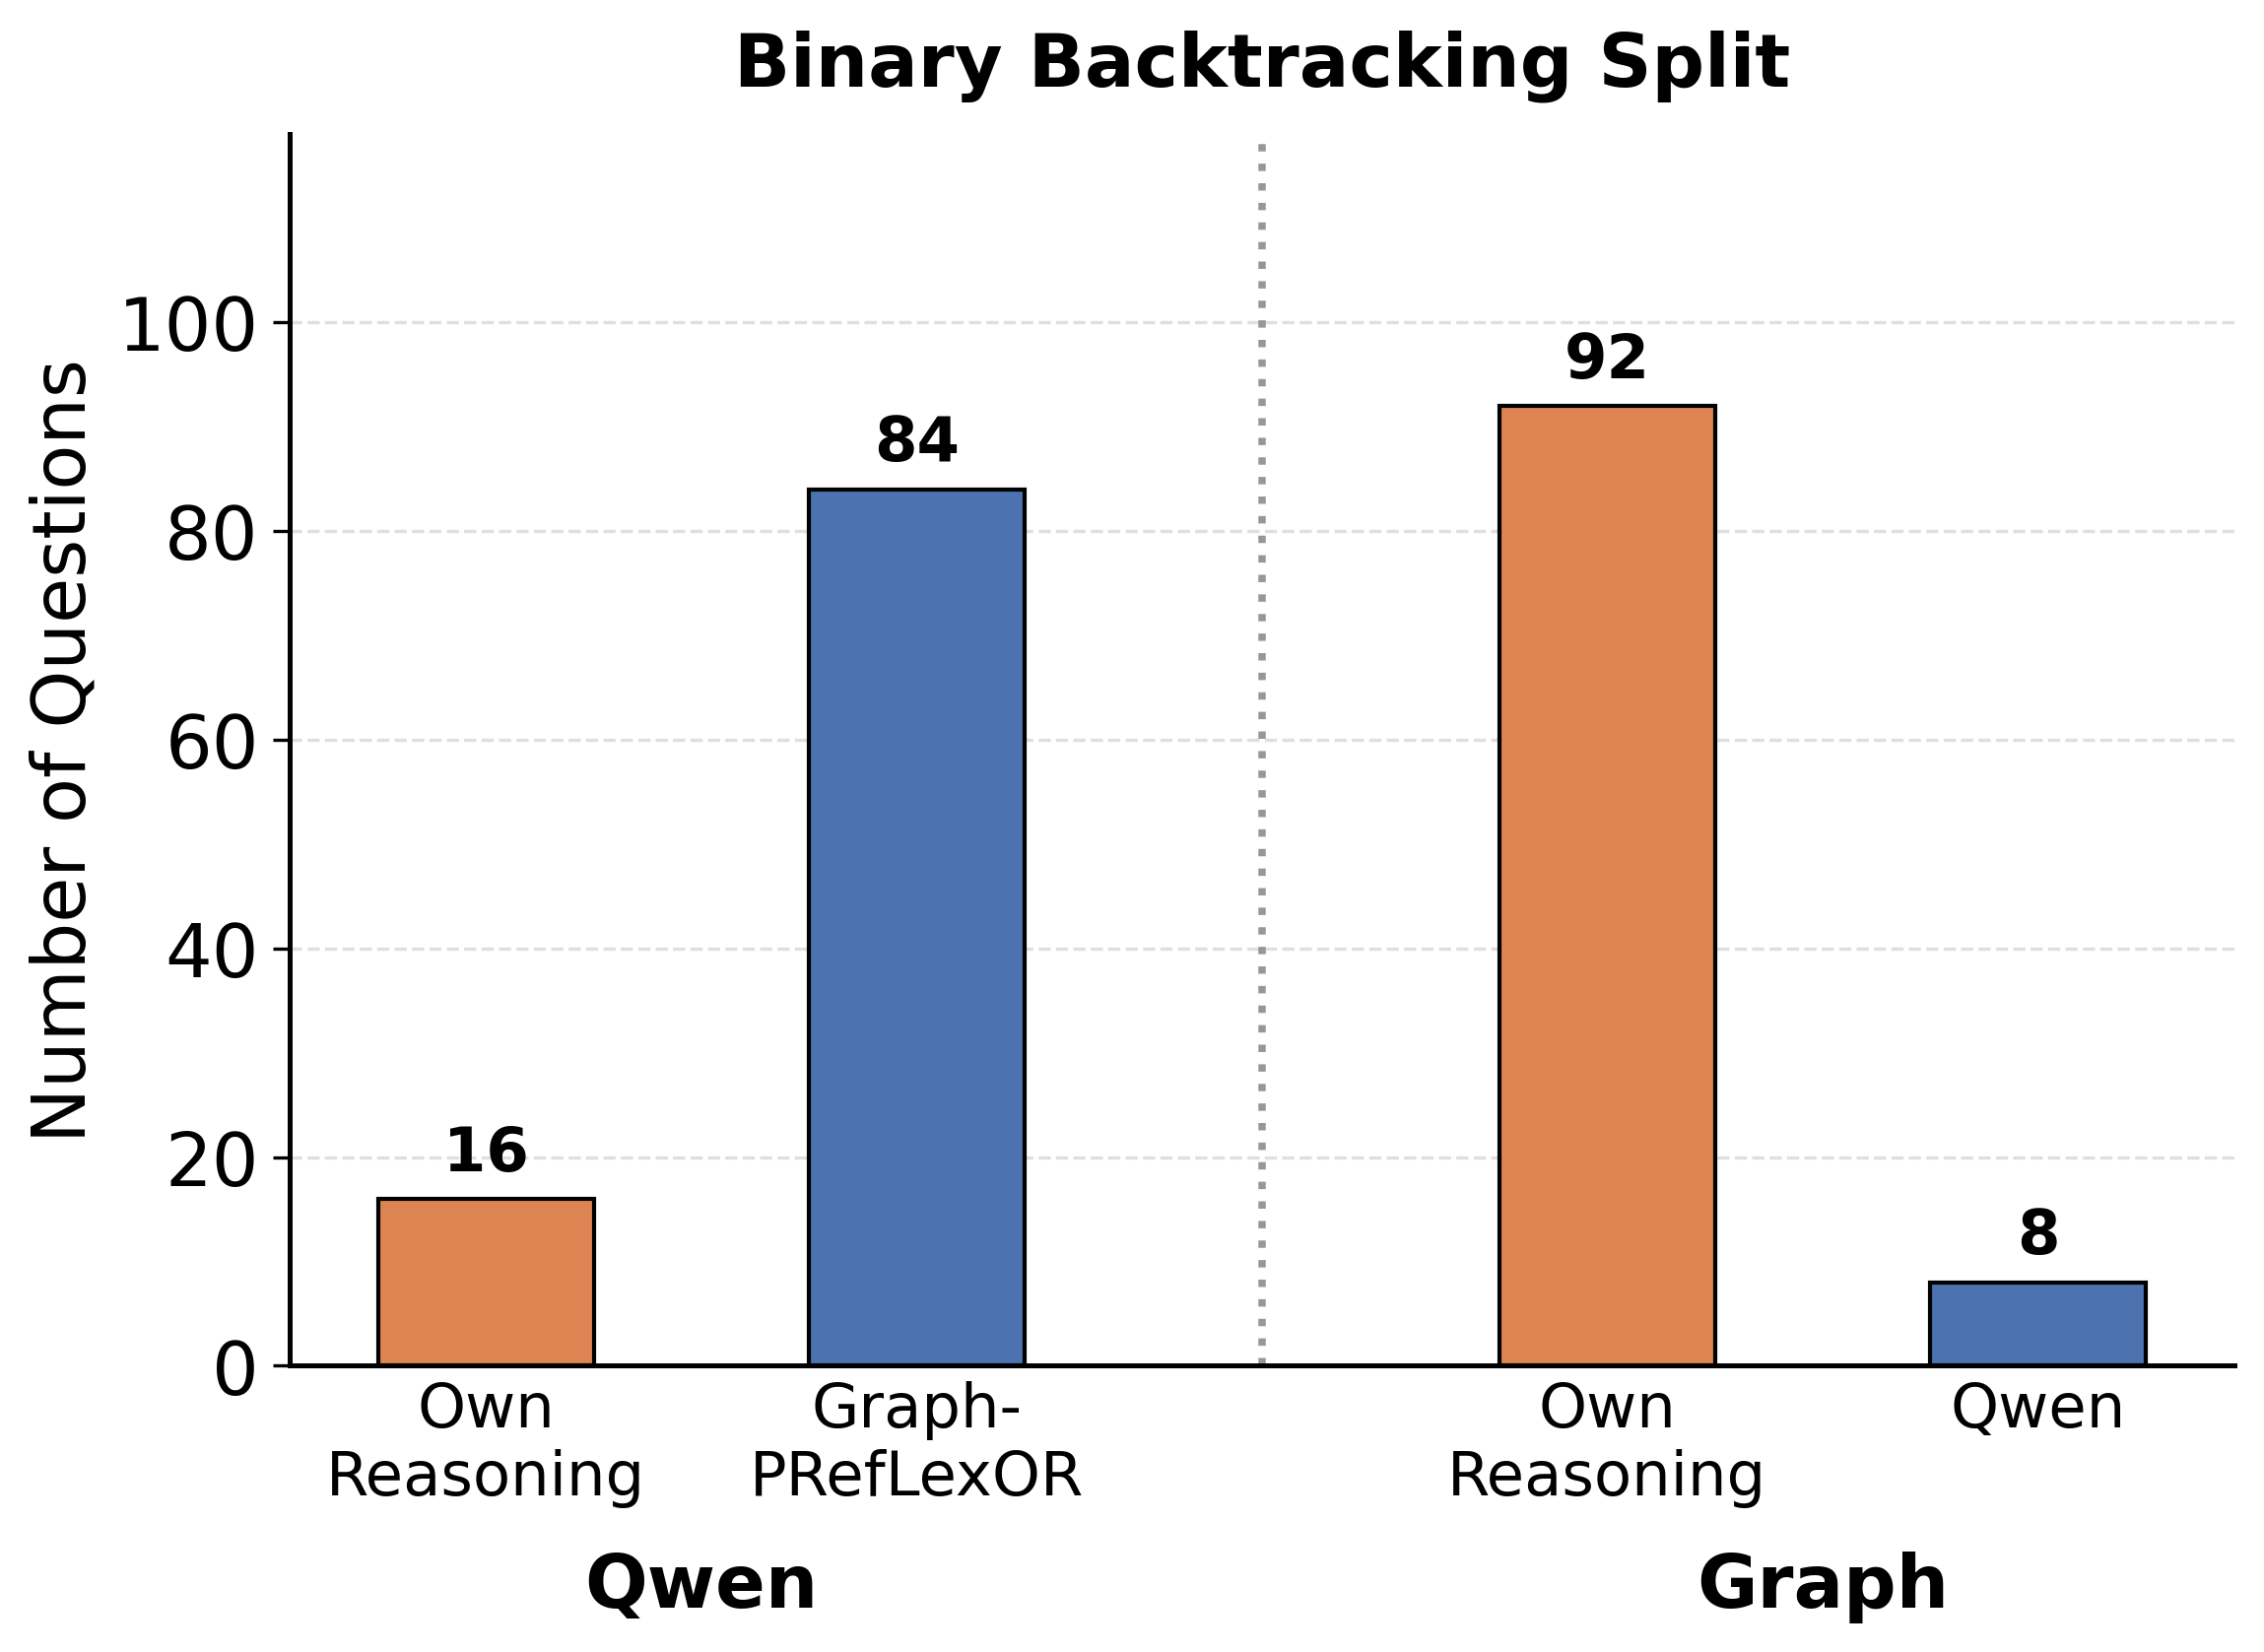

In [101]:
# ── Merged binary backtracking on ONE axes: Fig 8 (left) + Fig 9 (left) ──────
# 4 bars: first 2 = Qwen-8B answer, last 2 = Graph-PRefLexOR answer (gap between groups).
# Bar color = which model the answer is closest to (orange = Qwen, blue = Graph-PRefLexOR).
def plot_binary_merged(sim_df, results_dir):
    # Fig 8 left: Qwen answer — own thinking (16) vs Graph-PRefLexOR (84)
    qwen_own   = int((sim_df["closest_source"] == "qwen_thinking").sum())
    qwen_graph = len(sim_df) - qwen_own

    # Fig 9 left: Graph answer — own stages (92) vs Qwen (8)
    gdf = pd.read_csv(results_dir / "exp2_graph_full_backtracking_100.csv")
    own_stages = {"brainstorm", "graph", "patterns", "synthesis"}
    graph_own  = int(gdf["closest_source"].isin(own_stages).sum())
    graph_qwen = len(gdf) - graph_own

    n = len(sim_df)  # 100

    # layout: bars 0,1 (Qwen) | gap | bars 2.6,3.6 (Graph)
    x      = np.array([0, 1, 2.6, 3.6])
    counts = [qwen_own, qwen_graph, graph_own, graph_qwen]
    colors = [C_CORAL, C_BLUE, C_CORAL, C_BLUE]   # color = destination model
    ticks  = ["Own\nReasoning", "Graph-\nPRefLexOR", "Own\nReasoning", "Qwen"]

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    # plt.rcParams.update({"font.size": 20})
    bars = ax.bar(x, counts, color=colors, width=0.5, zorder=3,
                  edgecolor="black", linewidth=1)
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f"{v}", ha="center", va="bottom",
                fontsize=15, fontweight="bold")

    # dotted divider between the two groups (midpoint of the gap)
    ax.axvline(1.8, color=C_GRAY, linestyle=":", linewidth=1.8, alpha=0.9, zorder=2)

    ax.set_xticks(x)
    ax.set_xticklabels(ticks, fontsize=15)
    ax.tick_params(axis="x", length=0)
    ax.set_ylabel("Number of Questions")
    ax.set_ylim(0, 100 * 1.18)
    ax.grid(axis="y", alpha=0.4, linestyle="--"); ax.grid(axis="x", visible=False)

    # group labels beneath each pair (x in data coords, y in axes fraction)
    tr = ax.get_xaxis_transform()
    ax.text(0.5, -0.15, "Qwen", ha="center", va="top",
            fontweight="bold", color='black', transform=tr)
    ax.text(3.1, -0.15, "Graph", ha="center", va="top",
            fontweight="bold", color='black', transform=tr)

    # color key: which model the answer backtracks to
    from matplotlib.patches import Patch
#     ax.legend(handles=[Patch(facecolor=C_BLUE,  edgecolor="black", label="Closest to Graph-PRefLexOR"),
#                        Patch(facecolor=C_CORAL, edgecolor="black", label="Closest to Qwen")],
#               loc="upper right", fontsize=10)

    ax.set_title("Binary Backtracking Split", pad=12, fontweight="bold")
    fig.tight_layout()
    save(fig, "fig8_9_binary_backtracking_merged")

plot_binary_merged(sim_df, RESULTS)

---
## Plot 1 — Backtracking distribution

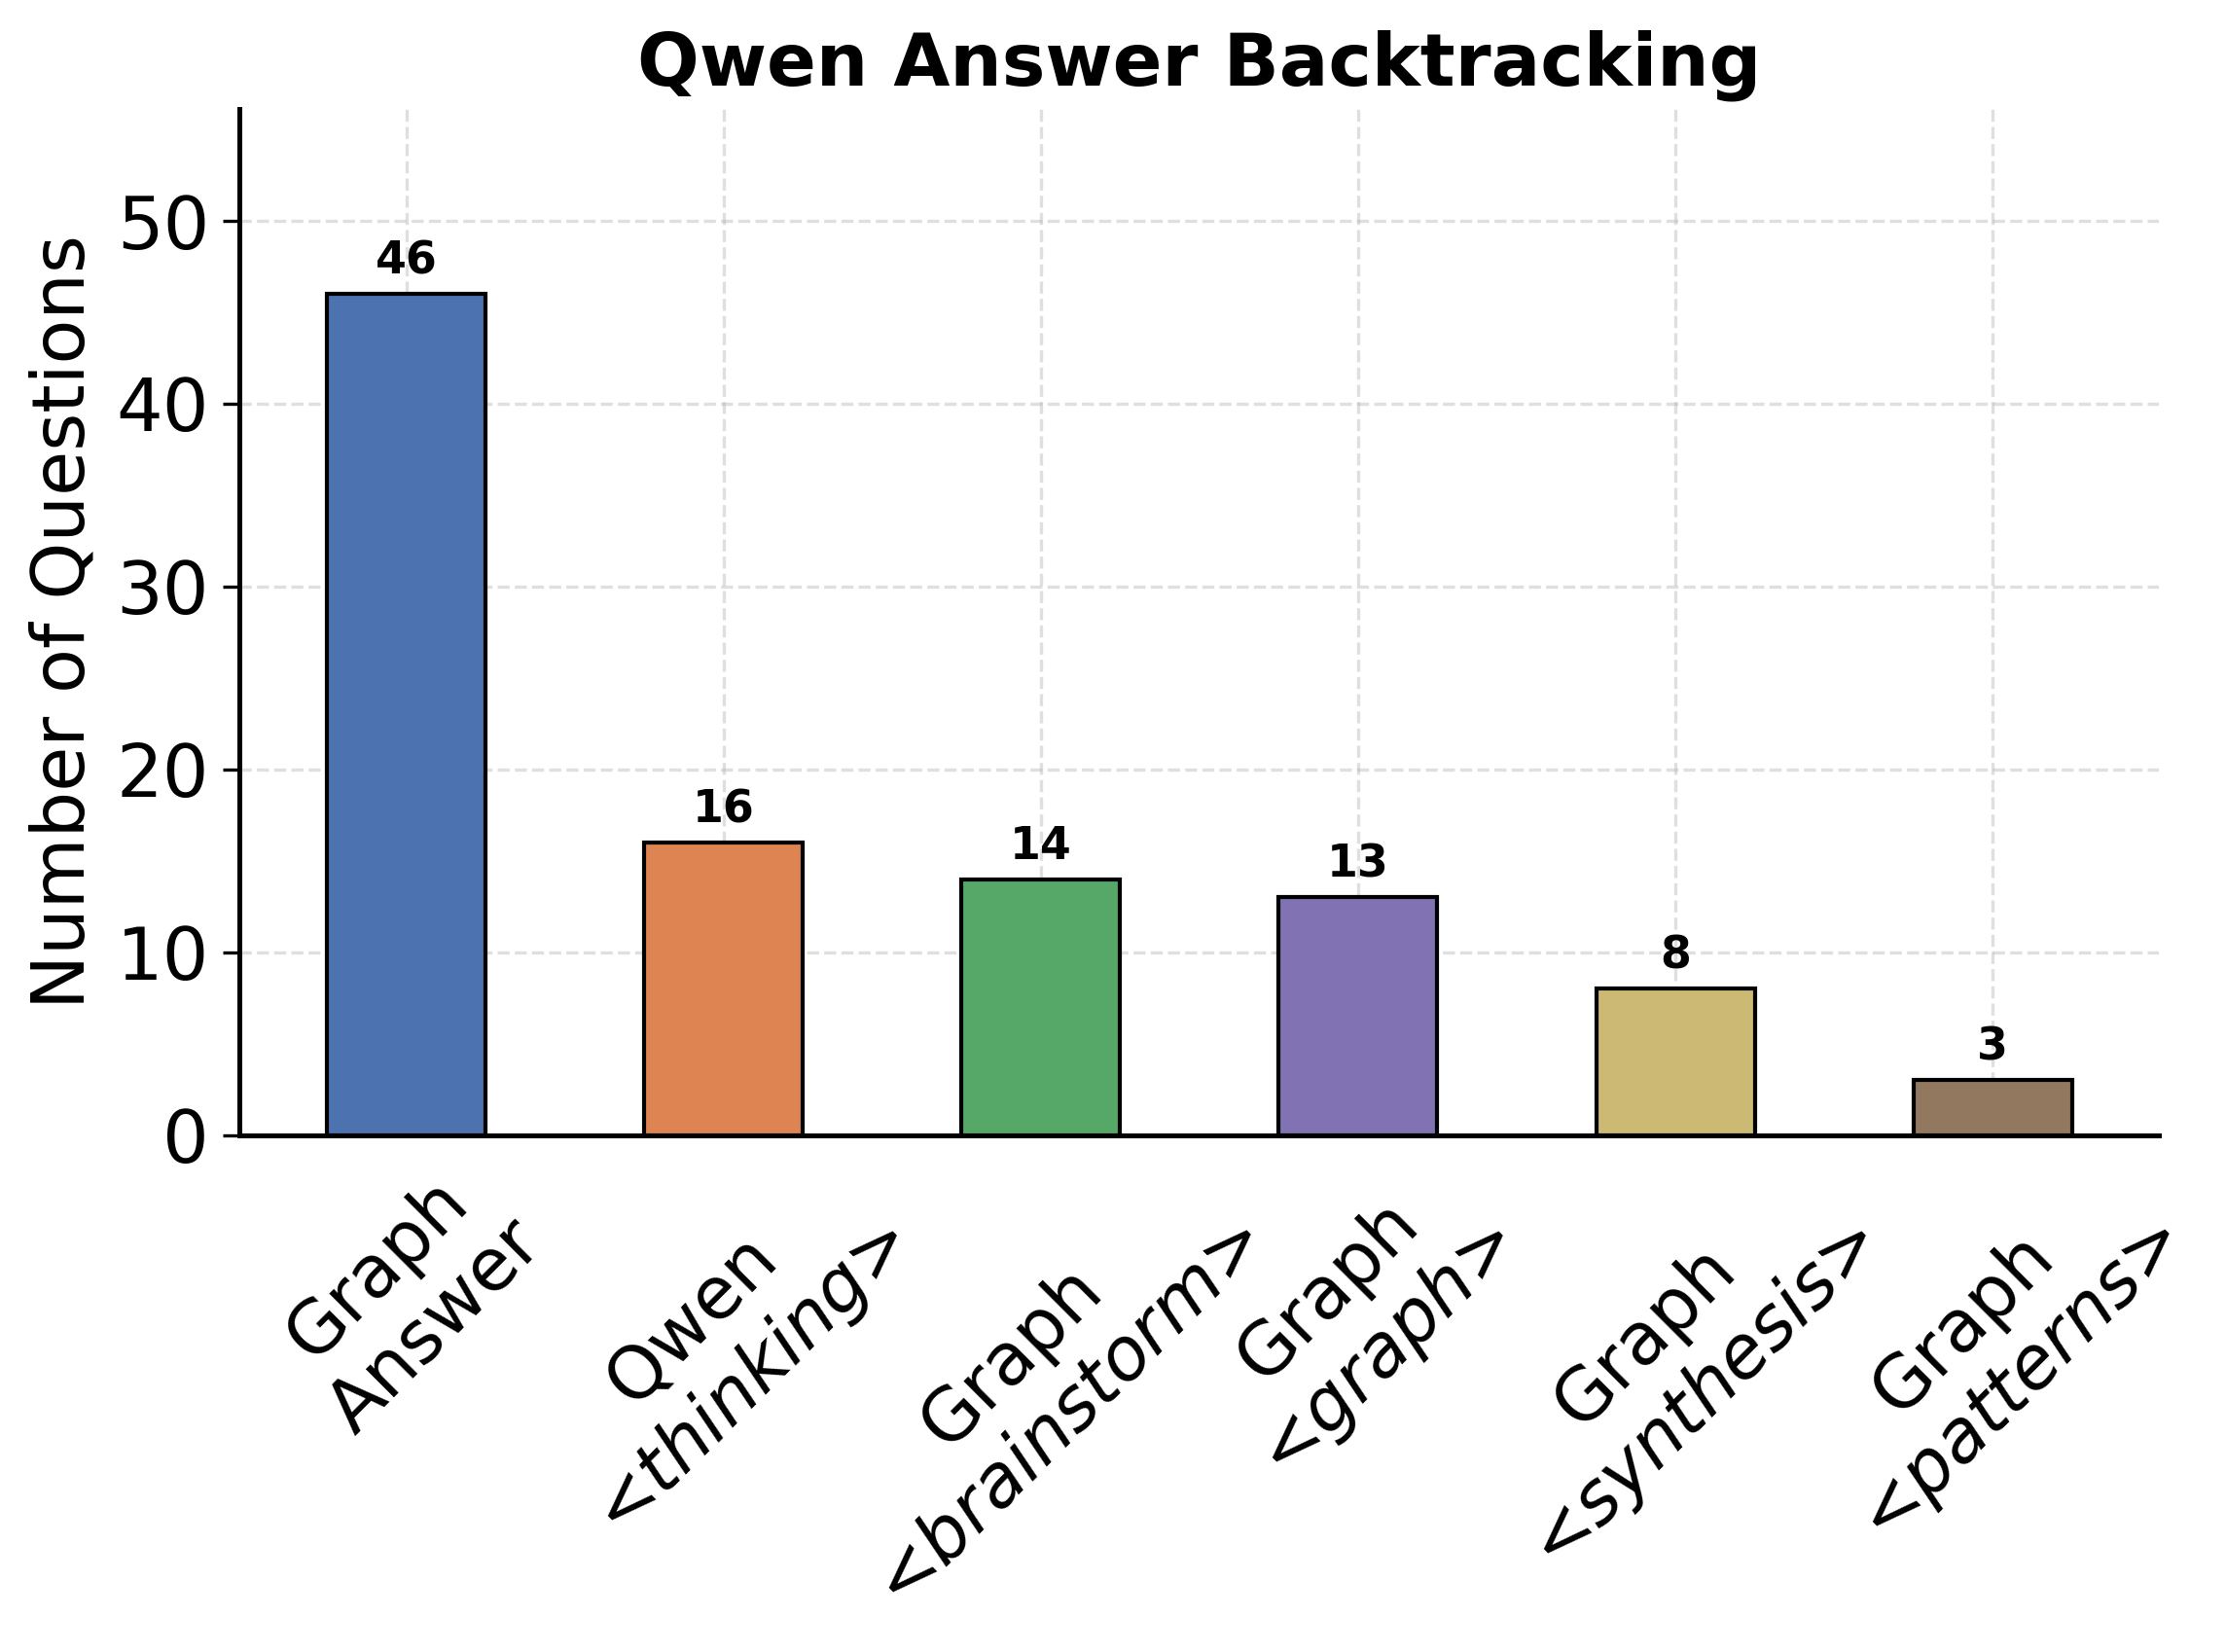

In [115]:
def plot1(sim_df):
    vc = sim_df["closest_source"].value_counts()
    nice = {
        "graph_answer":    "Graph\nAnswer",
        "qwen_thinking":   "Qwen\n<$\\mathit{thinking}$>",
        "graph_brainstorm":"Graph\n<$\\mathit{brainstorm}$>",
        "graph_graph":     "Graph\n<$\\mathit{graph}$>",
        "graph_synthesis": "Graph\n<$\\mathit{synthesis}$>",
        "graph_patterns":  "Graph\n<$\\mathit{patterns}$>",
    }

    labels = [nice.get(k, k) for k in vc.index]
    colors = [SOURCE_COLORS.get(k, C_GRAY) for k in vc.index]

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    bars = ax.bar(labels, vc.values, color=colors, width=0.5, zorder=3,
                  edgecolor="black", linewidth=1)
    ax.set_ylim(0, vc.max() * 1.22)
    bar_labels(ax, bars, fmt="{:.0f}")
    ax.set_ylabel("Number of Questions")
    ax.set_title("Qwen Answer Backtracking")
    ax.tick_params(axis="x", which="both", length=0, rotation=45)
    fig.tight_layout()
    save(fig, "plot1_backtrack_distribution")

plot1(sim_df)

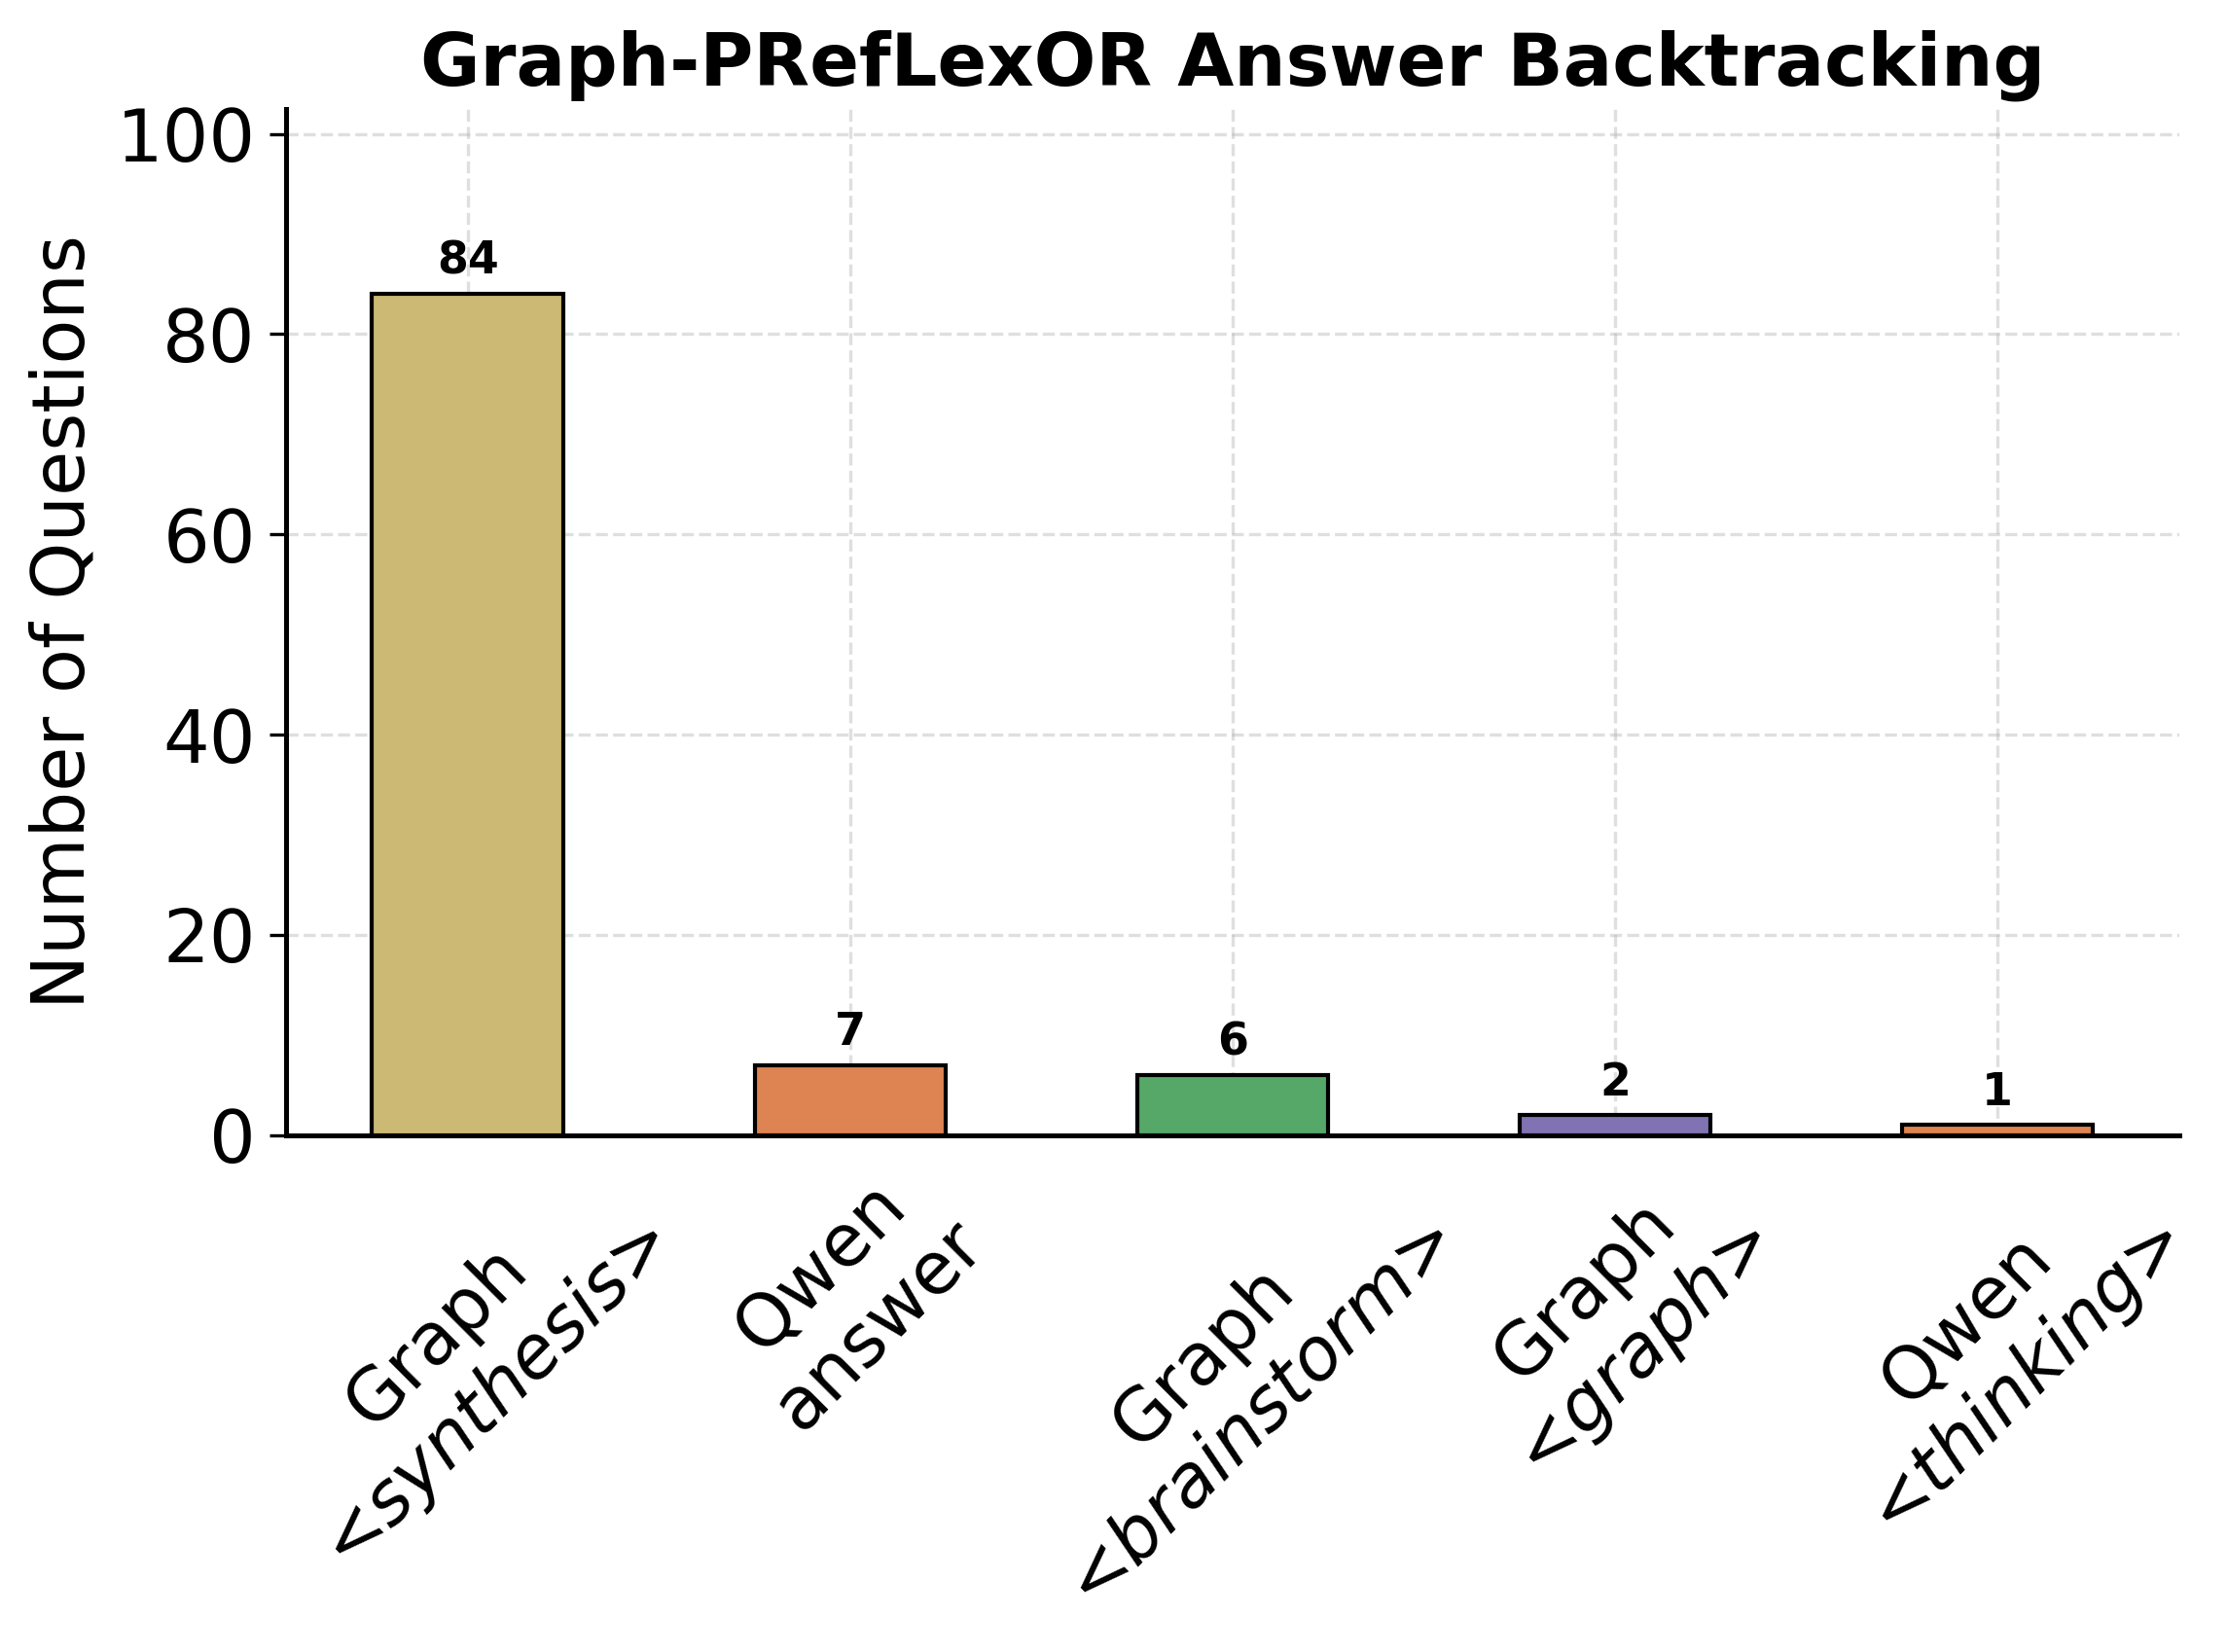

In [105]:
# Plot 1 (Graph-PRefLexOR) — where Graph-PRefLexOR's final answer backtracks to.
# Analog of plot1, from Graph-PRefLexOR's side: own stages + Qwen as candidate sources.
def plot1_graph(results_dir):
    gdf = pd.read_csv(results_dir / "exp2_graph_full_backtracking_100.csv")
    vc = gdf["closest_source"].value_counts()
    # mathtext ($\mathit{}$) italicizes only the word inside the < > brackets
    nice = {
        "synthesis":     "Graph\n<$\\mathit{synthesis}$>",
        "brainstorm":    "Graph\n<$\\mathit{brainstorm}$>",
        "graph":         "Graph\n<$\\mathit{graph}$>",
        "patterns":      "Graph\n<$\\mathit{patterns}$>",
        "qwen_answer":   "Qwen\nanswer",
        "qwen_thinking": "Qwen\n<$\\mathit{thinking}$>",
    }
    cmap = {
        "synthesis":     C_AMBER,
        "brainstorm":    C_GREEN,
        "graph":         C_PURPLE,
        "patterns":      C_BROWN,
        "qwen_answer":   C_CORAL,
        "qwen_thinking": C_CORAL,
    }
    labels = [nice.get(k, k) for k in vc.index]
    colors = [cmap.get(k, C_GRAY) for k in vc.index]

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    bars = ax.bar(labels, vc.values, color=colors, width=0.5, zorder=3,
                  edgecolor="black", linewidth=1)
    ax.set_ylim(0, vc.max() * 1.22)
    bar_labels(ax, bars, fmt="{:.0f}")
    ax.set_ylabel("Number of Questions")
    ax.set_title("Graph-PRefLexOR Answer Backtracking")
    ax.tick_params(axis="x", which="both", length=0, rotation=45)
    fig.tight_layout()
    save(fig, "plot1_graph_backtrack_distribution")

plot1_graph(RESULTS)

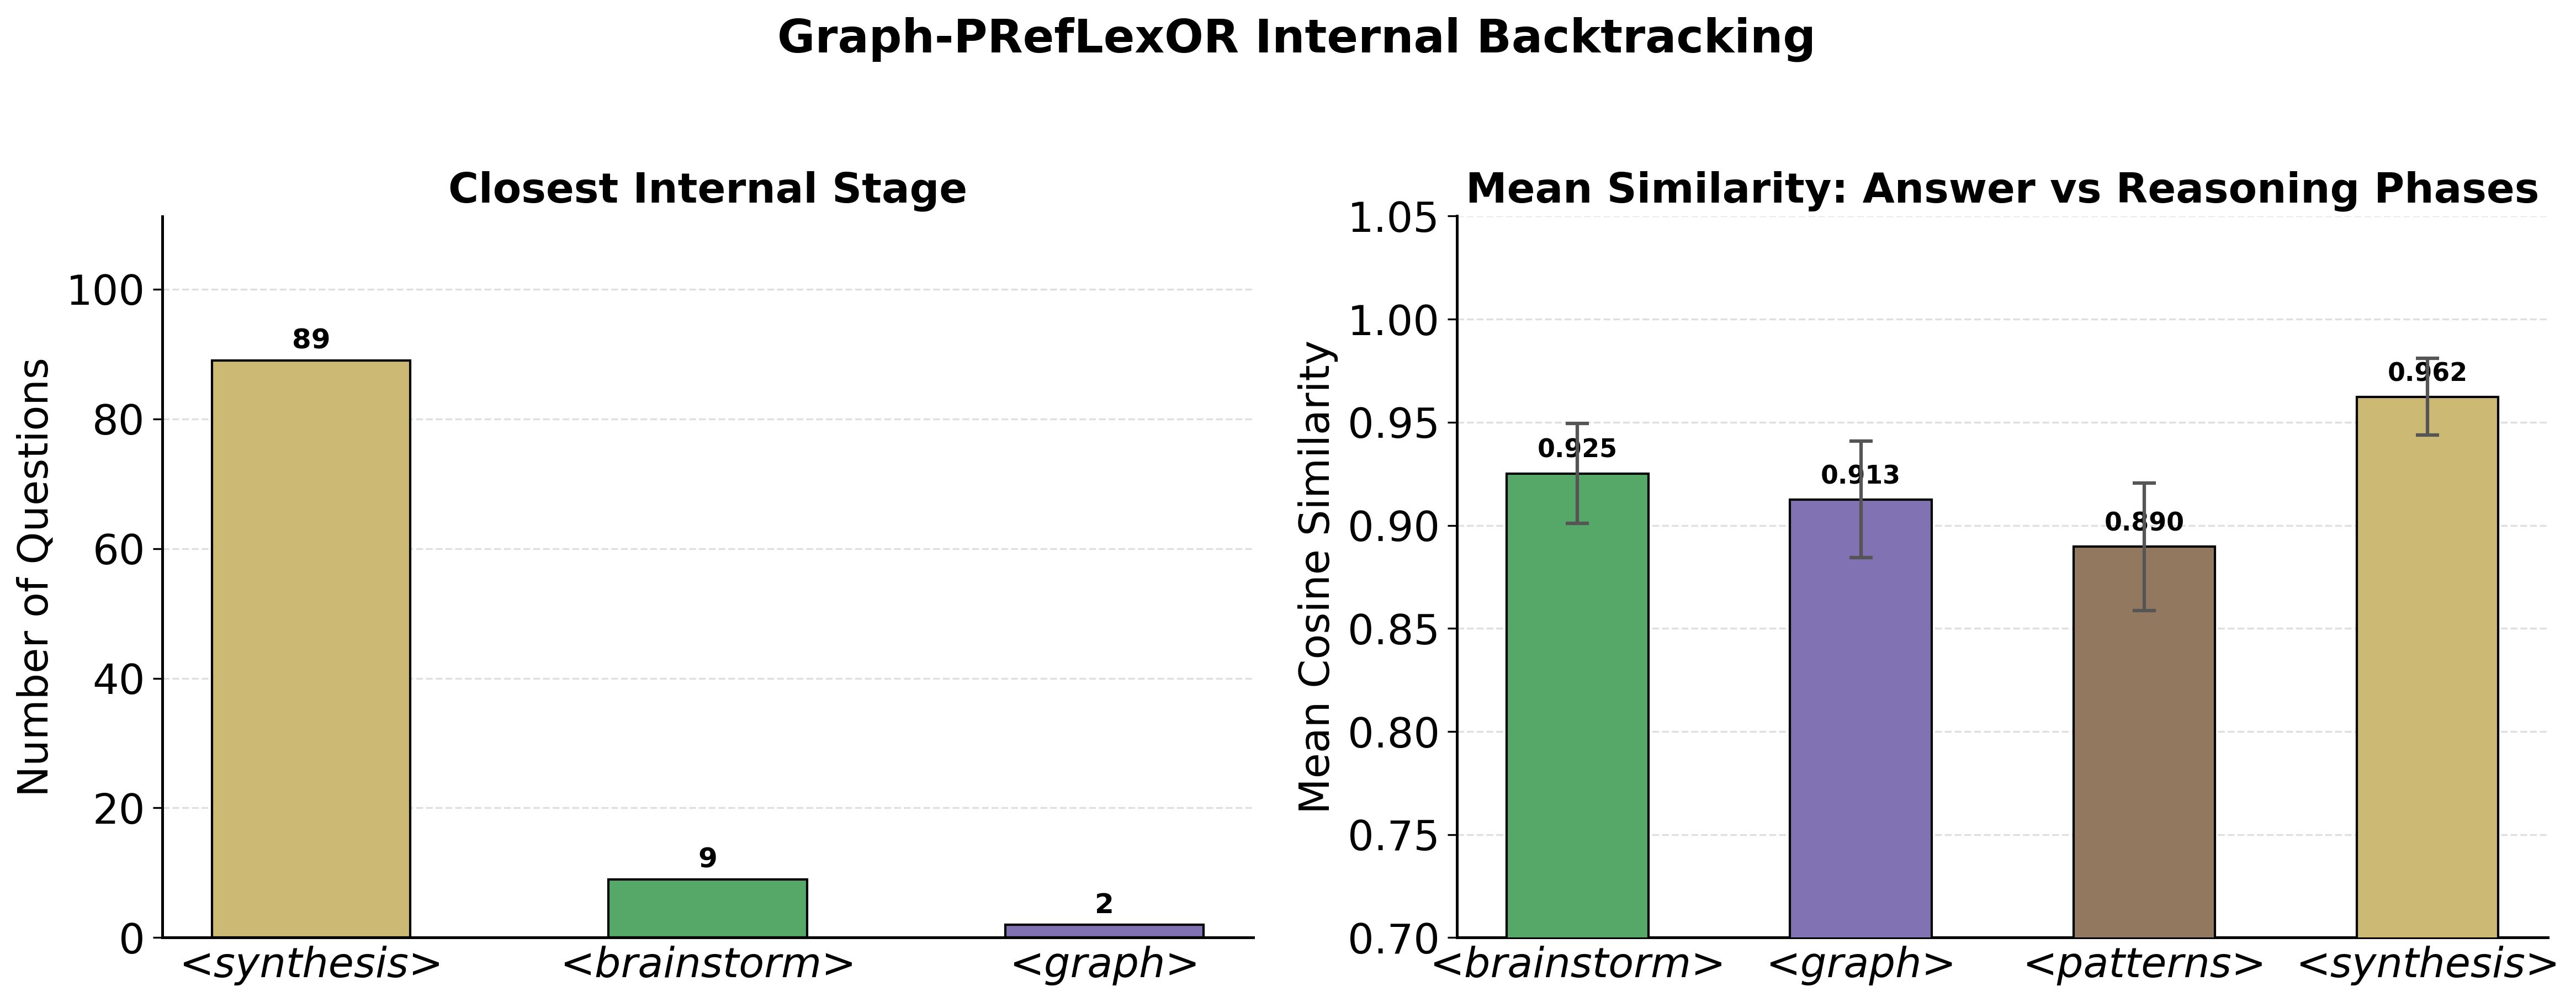

In [107]:
# Plot A2 — Graph-PRefLexOR internal backtracking (counts + mean similarity)
vc = graph_bt_df["closest_stage"].value_counts()
n  = len(graph_bt_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# Left: closest internal stage (counts)
ax = axes[0]
nice = {"brainstorm":"<brainstorm>","graph":"<graph>",
        "patterns":"<patterns>","synthesis":"<synthesis>"}
labels  = [nice.get(k, k) for k in vc.index]
colors  = [STAGE_COLORS.get(k, C_GRAY) for k in vc.index]
bars = ax.bar(labels, vc.values, color=colors, width=0.5, zorder=3,
              edgecolor="black", linewidth=1)
ax.set_ylim(0, vc.max()*1.25)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + vc.max()*0.02,
            f"{v}",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Questions")
# ax.set_xlabel("Thinking phases")
ax.set_title("Closest Internal Stage")
ax.tick_params(axis="x", length=0)
plt.setp(ax.get_xticklabels(), style="italic")

ax.grid(axis="y", alpha=0.4, linestyle="--")
ax.grid(axis="x", visible=False)

# Right: mean similarity (answer vs reasoning stages)
ax = axes[1]
sim_cols = [("sim_graph_answer_to_brainstorm","Brainstorm",C_GREEN),
            ("sim_graph_answer_to_graph","Graph",C_PURPLE),
            ("sim_graph_answer_to_patterns","Patterns",C_BROWN),
            ("sim_graph_answer_to_synthesis","Synthesis",C_AMBER)]
sim_cols = [(c,l,col) for c,l,col in sim_cols if c in graph_bt_df.columns]
labels2  = [l for _,l,_ in sim_cols]
means    = [graph_bt_df[c].mean() for c,_,_ in sim_cols]
stds     = [graph_bt_df[c].std()  for c,_,_ in sim_cols]
colors2  = [col for _,_,col in sim_cols]
x = np.arange(len(labels2))
bars2 = ax.bar(x, means, yerr=stds, color=colors2, width=0.5,
               capsize=5, zorder=3, edgecolor="black", linewidth=1,
               error_kw=dict(elinewidth=1.5, capthick=1.5, ecolor="#555"))
ax.set_ylim(0.7, 1.05)
ax.set_xticks(x); ax.set_xticklabels([f"<{l.lower()}>" for l in labels2], style="italic")
ax.set_ylabel("Mean Cosine Similarity")
ax.set_title("Mean Similarity: Answer vs Reasoning Phases")
ax.tick_params(axis="x", length=0)
for bar, m in zip(bars2, means):
    ax.text(bar.get_x()+bar.get_width()/2,
            m + 0.005, f"{m:.3f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.4, linestyle="--")
ax.grid(axis="x", visible=False)

fig.suptitle("Graph-PRefLexOR Internal Backtracking",
             fontsize=20, fontweight="bold", y=1.02)
fig.tight_layout()

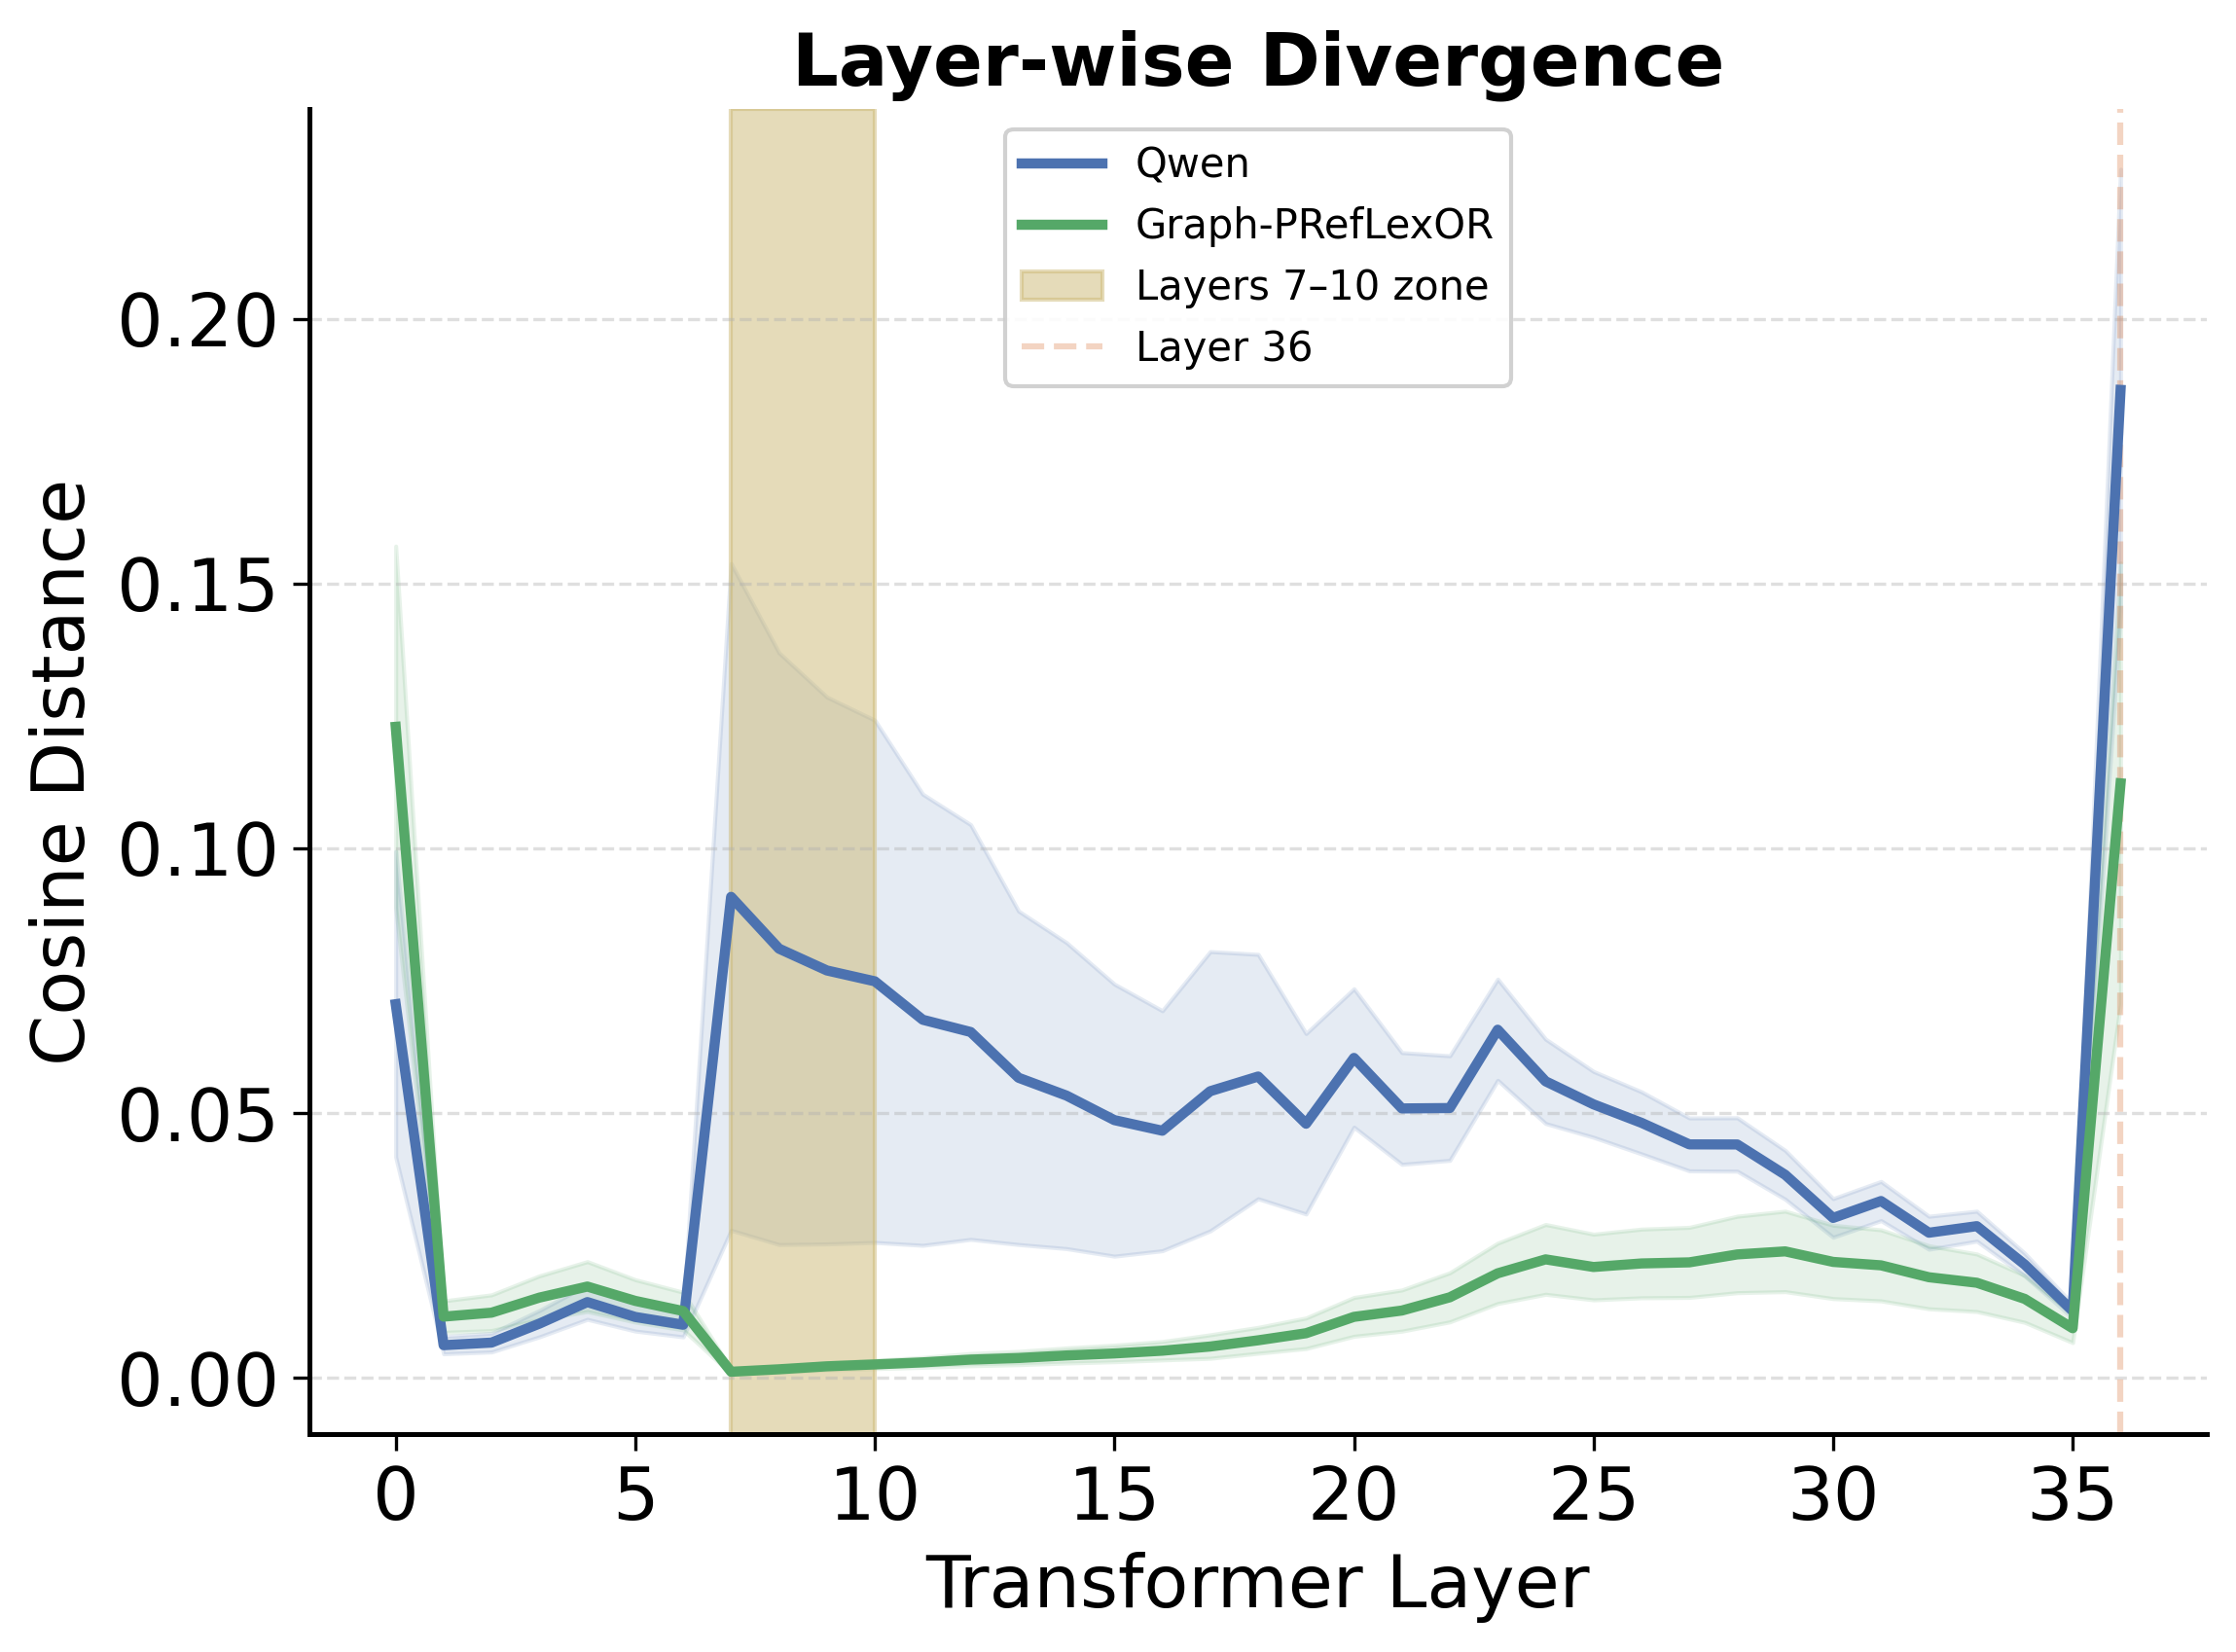

In [108]:
def plot_b(qwen_hidden, graph_hidden):
    q_stats = qwen_hidden.groupby("layer")["thinking_answer_cosine_distance"].agg(["mean","std"]).reset_index()
    g_combined = graph_hidden[graph_hidden["stage"]=="reasoning"]
    g_stats = g_combined.groupby("layer")["reasoning_answer_cosine_distance"].agg(["mean","std"]).reset_index()

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    ax.plot(q_stats["layer"], q_stats["mean"], color=C_BLUE, linewidth=2.5,
            label="Qwen", zorder=4)
    ax.fill_between(q_stats["layer"],
                    q_stats["mean"]-q_stats["std"],
                    q_stats["mean"]+q_stats["std"],
                    alpha=0.14, color=C_BLUE)

    ax.plot(g_stats["layer"], g_stats["mean"], color=C_GREEN, linewidth=2.5,
            label="Graph-PRefLexOR", zorder=4)
    ax.fill_between(g_stats["layer"],
                    g_stats["mean"]-g_stats["std"],
                    g_stats["mean"]+g_stats["std"],
                    alpha=0.14, color=C_GREEN)

    ax.axvspan(7, 10, alpha=0.5, color=C_AMBER, label="Layers 7–10 zone")
    ax.axvline(36, color=C_CORAL, alpha=0.35, linewidth=1.5,
               linestyle="--", label="Layer 36")

    ax.set_xlabel("Transformer Layer")
    ax.set_ylabel("Cosine Distance")
    ax.set_title("Layer-wise Divergence")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.4, linestyle="--")
    ax.grid(axis="x", visible=False)
    fig.tight_layout()
    save(fig, "plotB_qwen_vs_graph_layer_divergence")

plot_b(hidden_df, graph_hidden)

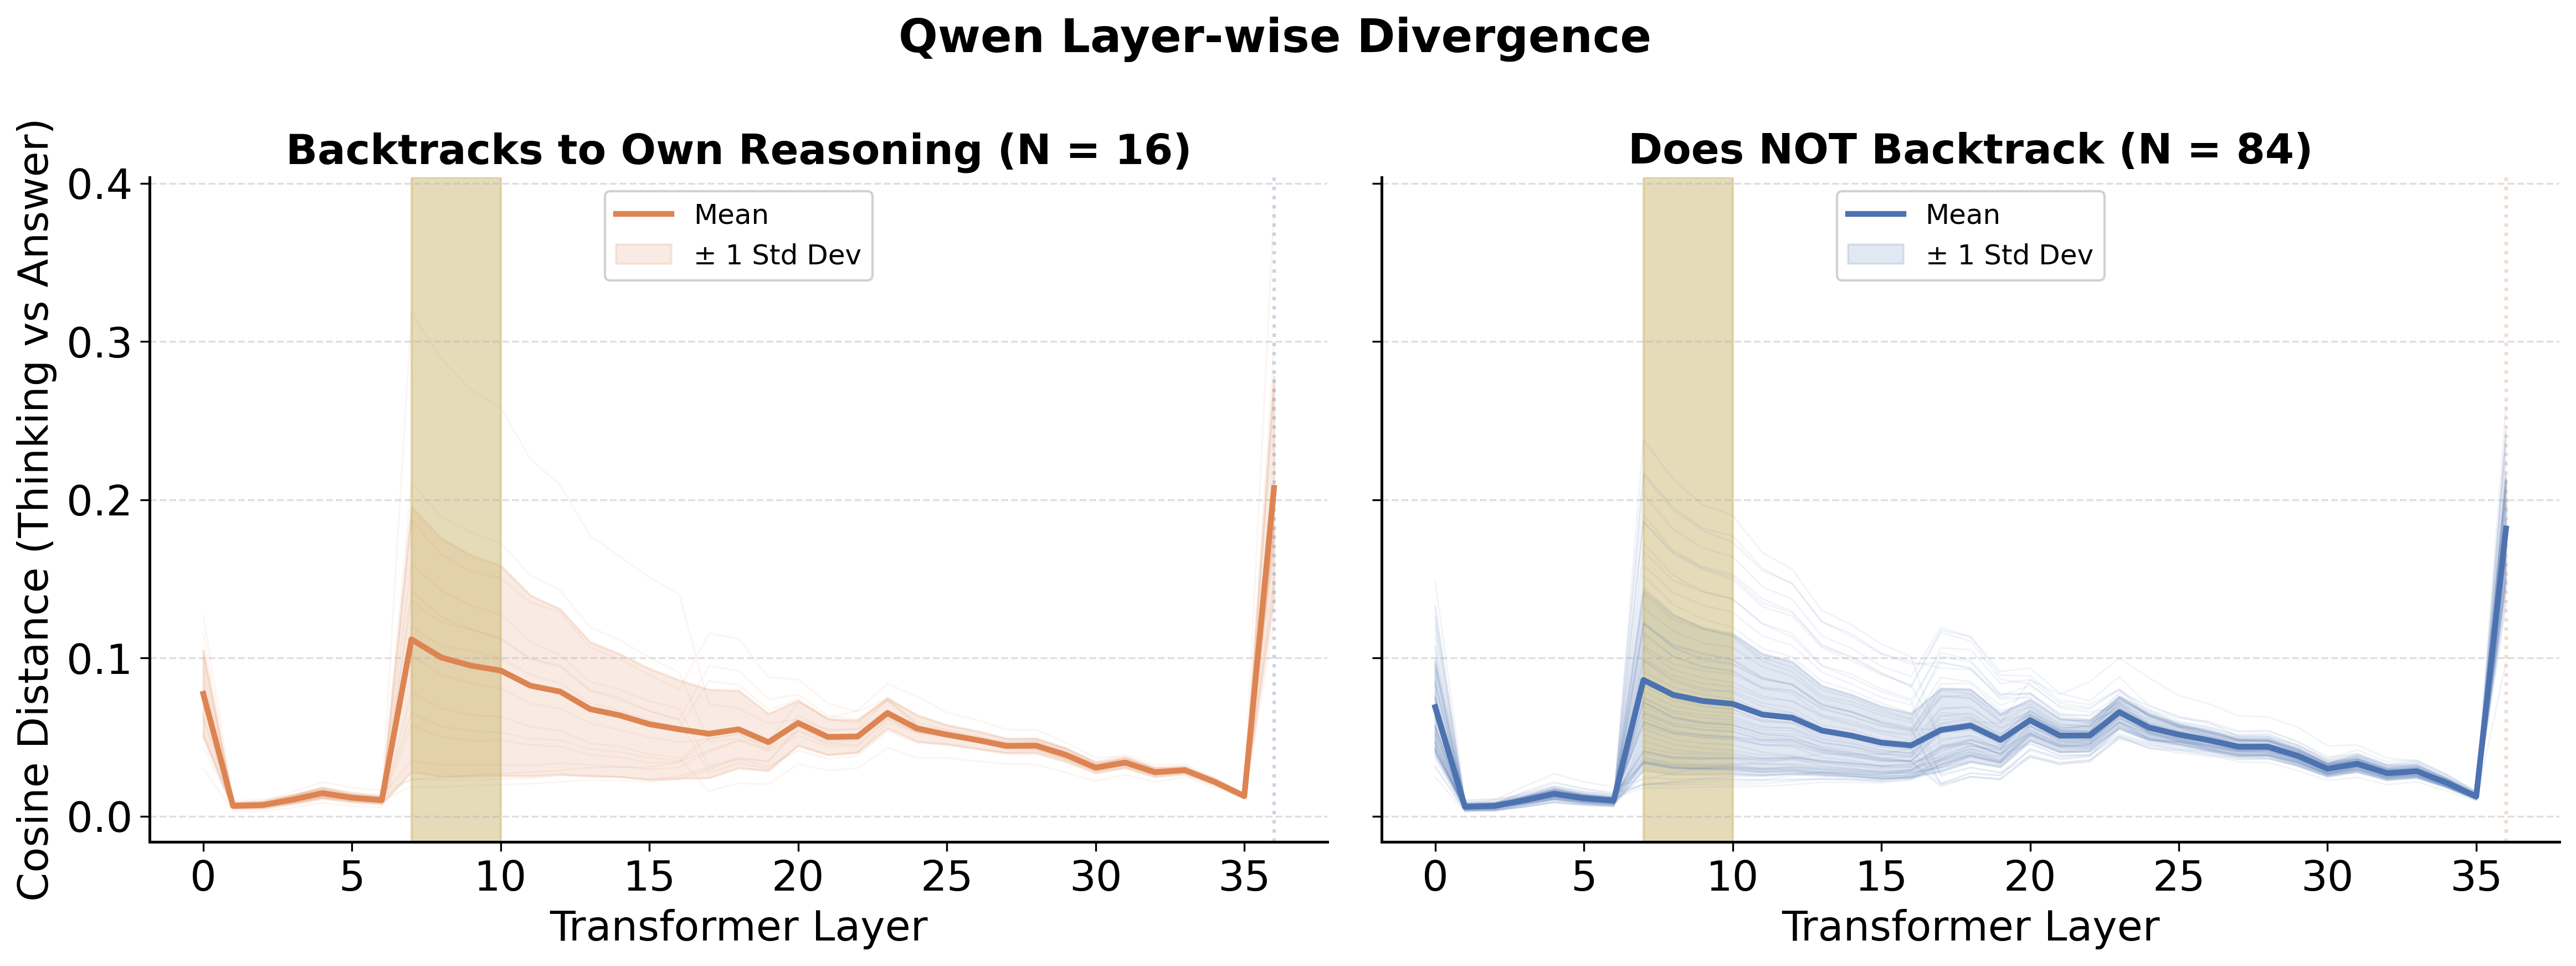

In [112]:
def plot_c1(qwen_hidden, sim_df):
    group_a = set(sim_df[sim_df["closest_source"]=="qwen_thinking"]["id"])
    group_b = set(sim_df[sim_df["closest_source"]!="qwen_thinking"]["id"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, dpi=300)

    for ax, grp_ids, label, color in [
        (axes[0], group_a, f"Backtracks to Own Reasoning (N = {len(group_a)})", C_CORAL),
        (axes[1], group_b, f"Does NOT Backtrack (N = {len(group_b)})", C_BLUE),
    ]:
        df_g = qwen_hidden[qwen_hidden["id"].isin(grp_ids)]
        if df_g.empty:
            ax.text(0.5,0.5,"No data",ha="center",transform=ax.transAxes); continue

        for qid, grp in df_g.groupby("id"):
            g = grp.sort_values("layer")
            ax.plot(g["layer"], g["thinking_answer_cosine_distance"],
                    color=color, alpha=0.08, linewidth=0.7)

        st = df_g.groupby("layer")["thinking_answer_cosine_distance"].agg(["mean","std"]).reset_index()
        ax.plot(st["layer"], st["mean"], color=color, linewidth=2.5,
                label="Mean", zorder=4)
        ax.fill_between(st["layer"], st["mean"]-st["std"], st["mean"]+st["std"],
                        alpha=0.16, color=color, label="± 1 Std Dev")

        ax.axvspan(7, 10, alpha=0.5, color=C_AMBER)
        ax.axvline(36, color=C_CORAL if color!=C_CORAL else C_BLUE,
                   alpha=0.3, linewidth=1.5, linestyle=":")
        ax.set_title(label, fontsize=18)
        ax.set_xlabel("Transformer Layer")
        ax.legend(fontsize=12)
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.grid(axis="x", visible=False)
        if ax == axes[0]:
            ax.set_ylabel("Cosine Distance (Thinking vs Answer)")

    fig.suptitle("Qwen Layer-wise Divergence",
                 fontsize=20, fontweight="bold")
    fig.tight_layout()
    save(fig, "plotC1_qwen_divergence_by_backtrack_group")

plot_c1(hidden_df, sim_df)

In [ ]:
def plot_c2(graph_hidden, results_dir=RESULTS):
    # Split by the FULL cross-model backtracking (own reasoning stages vs Qwen outputs),
    # mirroring plot_c1's Qwen own-thinking-vs-other split. This matches the 92/8 own-vs-Qwen
    # split reported in Fig 8c / Fig 9 (left) and Section 2.5.
    # NOTE: the internal-only file (closest_stage) cannot represent "does NOT backtrack to own
    # reasoning" — every example there is already own-reasoning — so it is not used for this split.
    gdf = pd.read_csv(results_dir / "exp2_graph_full_backtracking_100.csv")
    own_stages = {"brainstorm", "graph", "patterns", "synthesis"}
    group_a = set(gdf[gdf["closest_source"].isin(own_stages)]["id"])    # backtracks to own reasoning (92)
    group_b = set(gdf[~gdf["closest_source"].isin(own_stages)]["id"])   # aligns with Qwen outputs (8)
    df_comb = graph_hidden[graph_hidden["stage"]=="reasoning"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, dpi=300)

    for ax, grp_ids, label, color in [
        (axes[0], group_a, f"Backtracks to Own Reasoning (N = {len(group_a)})", C_GREEN),
        (axes[1], group_b, f"Does NOT Backtrack (N = {len(group_b)})", C_CORAL),
    ]:
        df_g = df_comb[df_comb["id"].isin(grp_ids)]
        if df_g.empty:
            ax.text(0.5,0.5,"No data",ha="center",transform=ax.transAxes); continue

        for qid, grp in df_g.groupby("id"):
            g = grp.sort_values("layer")
            ax.plot(g["layer"], g["reasoning_answer_cosine_distance"],
                    color=color, alpha=0.09, linewidth=0.7)

        st = df_g.groupby("layer")["reasoning_answer_cosine_distance"].agg(["mean","std"]).reset_index()
        ax.plot(st["layer"], st["mean"], color=color, linewidth=2.5,
                label="Mean", zorder=4)
        ax.fill_between(st["layer"], st["mean"]-st["std"], st["mean"]+st["std"],
                        alpha=0.16, color=color, label="± 1 Std Dev")

        # ax.axvspan(7, 10, alpha=0.07, color=C_AMBER)
        ax.axvline(36, color=C_BLUE, alpha=0.3, linewidth=1.5, linestyle=":")
        ax.set_title(label, fontsize=18)
        ax.set_xlabel("Transformer Layer")
        ax.legend(fontsize=12)
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.grid(axis="x", visible=False)
        if ax == axes[0]:
            ax.set_ylabel("Cosine Distance (Reasoning vs Answer)")

    fig.suptitle("Graph-PRefLexOR Layer-wise Divergence",
                 fontsize=20, fontweight="bold")
    fig.tight_layout()
    save(fig, "plotC2_graph_divergence_by_stage_group")

plot_c2(graph_hidden)
